# Example-06: Coupled twiss parameters

In [1]:
# Import

import numpy
import pandas
import torch
import yaml

import sys
sys.path.append('..')

from harmonica.util import mod
from harmonica.statistics import mean, variance
from harmonica.statistics import weighted_mean, weighted_variance
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter
from harmonica.decomposition import Decomposition
from harmonica.model import Model
from harmonica.table import Table

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())

True


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

In [3]:
# In this example twiss parameters are computed for coupled model
# A thin skew quadrupole is added to the one-turn matrix

In [4]:
# Load uncoupled model

model = Model(path='../config_uncoupled.yaml', model='uncoupled', dtype=dtype, device=device)

In [5]:
# Generate one-turn matrix at the 'HEAD' location

from harmonica.parameterization import is_symplectic

matrix = model.matrix(0, model.size)
print(matrix)
print(is_symplectic(matrix))

tensor([[-8.174741941785e-01, -1.715086192481e+00, 0.000000000000e+00, 0.000000000000e+00],
        [4.490851430614e-02, -1.129060750494e+00, 0.000000000000e+00, 0.000000000000e+00],
        [0.000000000000e+00, 0.000000000000e+00, -1.189482037211e+00, -7.354804784961e+00],
        [0.000000000000e+00, 0.000000000000e+00, 4.179161971876e-02, -5.822961370188e-01]],
       dtype=torch.float64)
True


In [6]:
# Generate thin skew quadrupole matrix

kn = torch.tensor(0.0E+0, dtype=dtype, device=device)
ks = torch.tensor(1.0E-3, dtype=dtype, device=device)

kick = model.matrix_kick(kn, ks)
print(kick)
print(is_symplectic(kick))

tensor([[1.000000000000e+00, 0.000000000000e+00, 0.000000000000e+00, 0.000000000000e+00],
        [-0.000000000000e+00, 1.000000000000e+00, 1.000000000000e-03, 0.000000000000e+00],
        [0.000000000000e+00, 0.000000000000e+00, 1.000000000000e+00, 0.000000000000e+00],
        [1.000000000000e-03, 0.000000000000e+00, 0.000000000000e+00, 1.000000000000e+00]],
       dtype=torch.float64)
True


In [7]:
# Compute twiss

from harmonica.parameterization import twiss_compute
tunes, normal, wolski = twiss_compute(kick @ matrix)
print(normal)
print(wolski)

tensor([[ 2.733011863453e+00,  3.346974230610e-16, -3.905040791675e-02,
         -3.197711738640e-17],
        [ 2.483160755541e-01,  3.657457500809e-01, -1.556901758468e-03,
         -1.056393628436e-02],
        [ 1.149739330129e-01, -2.319086872520e-16,  3.980640003650e+00,
          0.000000000000e+00],
        [-3.379408681657e-03,  3.587996081379e-03, -1.643330967144e-01,
          2.511122515631e-01]], dtype=torch.float64)
tensor([[[ 7.469353845777e+00,  6.786507803756e-01,  3.142251229120e-01,
          -9.235964018426e-03],
         [ 6.786507803756e-01,  1.954308270809e-01,  2.854987583677e-02,
           4.731328165488e-04],
         [ 3.142251229120e-01,  2.854987583677e-02,  1.321900527245e-02,
          -3.885439073879e-04],
         [-9.235964018426e-03,  4.731328165488e-04, -3.885439073879e-04,
           2.429411891765e-05]],

        [[ 1.524934358464e-03,  6.079764875449e-05, -1.554456159123e-01,
           6.417274460920e-03],
         [ 6.079764875449e-05,  1.14020

In [8]:
# Propagate twiss

# Generate transport matrices between locations

index = torch.arange(model.size, dtype=torch.int64, device=device)
transport = model.matrix(torch.zeros_like(index), index + 1)

# Apply error 

transport[-1] = kick @ transport[-1]

# Compute twiss

from harmonica.parameterization import twiss_propagate
table = twiss_propagate(wolski, transport).roll(1, 0)
print(table.shape)
print(torch.allclose(wolski, table[0]))

torch.Size([59, 2, 4, 4])
True


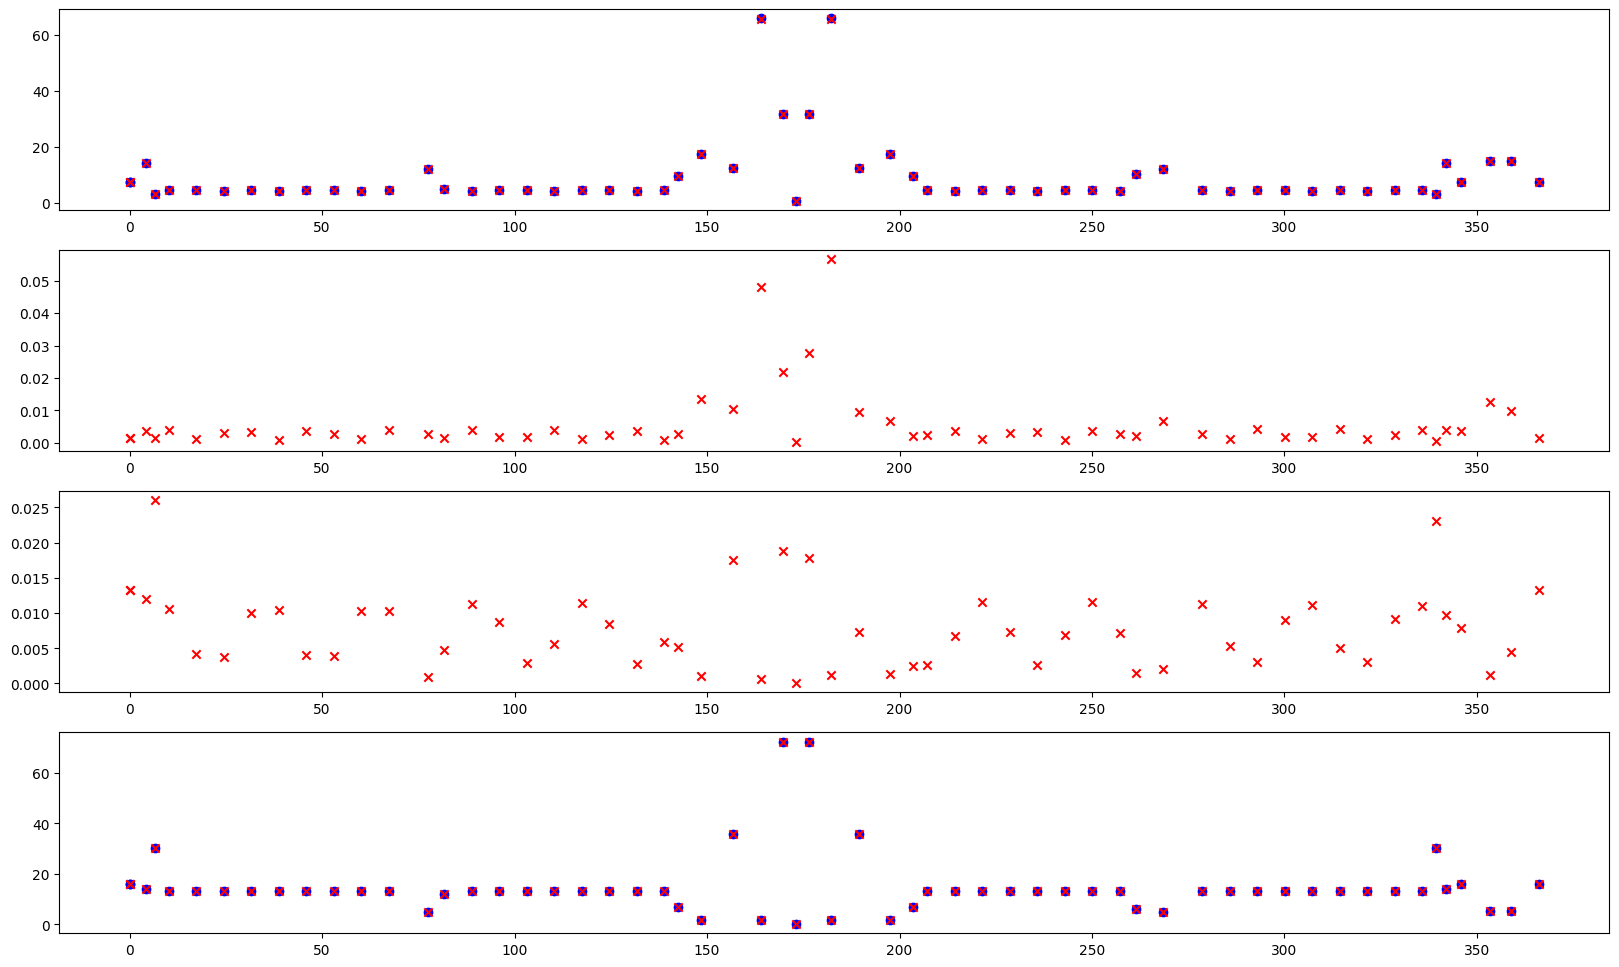

In [9]:
# Convert Wolski to Lebedev-Bogacz twiss and plot beta values

bxx = torch.zeros(model.size, dtype=dtype, device=device)
bxy = torch.zeros(model.size, dtype=dtype, device=device)
byx = torch.zeros(model.size, dtype=dtype, device=device)
byy = torch.zeros(model.size, dtype=dtype, device=device)

from harmonica.parameterization import wolski_to_lb
for i in range(model.size):
    _, bxx[i], _, bxy[i], _, byx[i], _, byy[i], *_ = wolski_to_lb(table[i])

plt.figure(figsize=(20, 3*4))

ax1 = plt.subplot(411)
ax1.scatter(model.time.cpu().numpy(),  model.bx.cpu().numpy(), marker='o', color='blue')
ax1.scatter(model.time.cpu().numpy(),  bxx.cpu().numpy(), marker='x', color='red')

ax2 = plt.subplot(412)
ax2.scatter(model.time.cpu().numpy(),  bxy.cpu().numpy(), marker='x', color='red')

ax3 = plt.subplot(413)
ax3.scatter(model.time.cpu().numpy(),  byx.cpu().numpy(), marker='x', color='red')

ax4 = plt.subplot(414)
ax4.scatter(model.time.cpu().numpy(),  model.by.cpu().numpy(), marker='o', color='blue')
ax4.scatter(model.time.cpu().numpy(),  byy.cpu().numpy(), marker='x', color='red')

plt.show()

In [10]:
# Generate trajectories from uncoupled and coupled one-turn matrices

m1 = matrix
tunes1, normal1, wolski1 = twiss_compute(m1)

m2 = kick @ matrix
tunes2, normal2, wolski2 = twiss_compute(m2)

initial = torch.tensor([
    [1.0E-3, 0.0, 1.0E-3, 0.0], 
    [2.0E-3, 0.0, 2.0E-3, 0.0], 
    [3.0E-3, 0.0, 3.0E-3, 0.0], 
    [4.0E-3, 0.0, 4.0E-3, 0.0], 
    [5.0E-3, 0.0, 5.0E-3, 0.0]], dtype=dtype, device=device)

length = 4096

table1 = torch.zeros((length, 4, len(initial)), dtype=dtype, device=device)
table2 = torch.zeros((length, 4, len(initial)), dtype=dtype, device=device)

table1[0] = initial.T
table2[0] = initial.T

floquet1 = torch.zeros((length, 4, len(initial)), dtype=dtype, device=device)
floquet2 = torch.zeros((length, 4, len(initial)), dtype=dtype, device=device)
floquet3 = torch.zeros((length, 4, len(initial)), dtype=dtype, device=device)

floquet1[0] = torch.matmul(normal1.inverse(), table1[0])
floquet2[0] = torch.matmul(normal2.inverse(), table2[0])
floquet3[0] = torch.matmul(normal1.inverse(), table2[0])

for i in range(1, length):
    
    table1[i] = torch.matmul(m1, table1[i - 1])
    table2[i] = torch.matmul(m2, table2[i - 1])
    
    floquet1[i] = torch.matmul(normal1.inverse(), table1[i])
    floquet2[i] = torch.matmul(normal2.inverse(), table2[i])
    floquet3[i] = torch.matmul(normal1.inverse(), table2[i])
    
table1 = table1.swapaxes(0, -1)
table2 = table2.swapaxes(0, -1)

floquet1 = floquet1.swapaxes(0, -1)
floquet2 = floquet2.swapaxes(0, -1)
floquet3 = floquet3.swapaxes(0, -1)

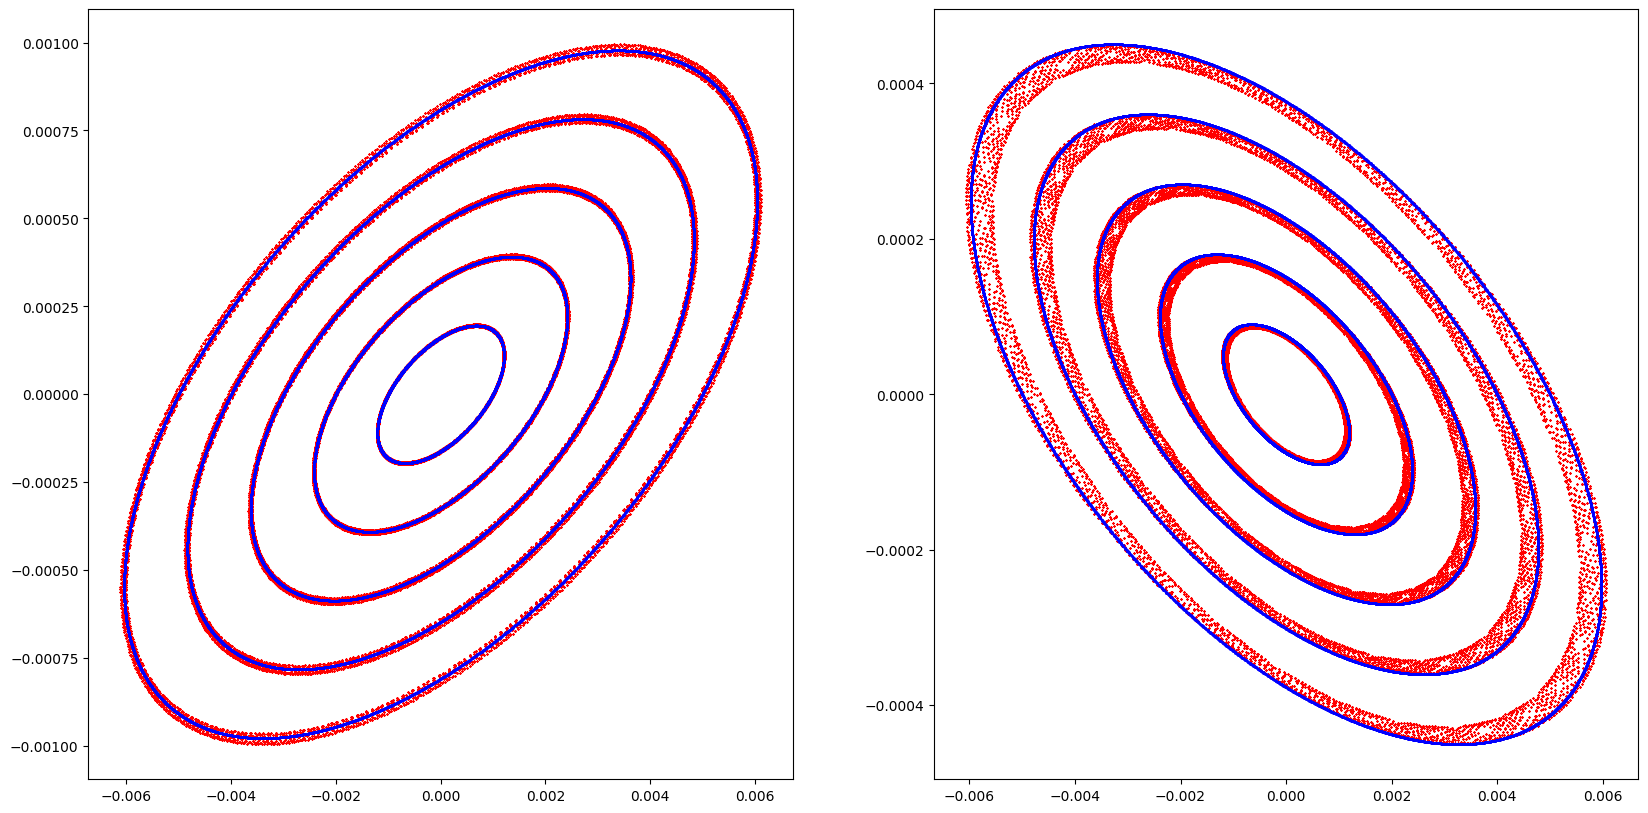

In [11]:
# Plot trajectories
# blue -- uncoupled, red -- coupled

plt.figure(figsize=(2*10, 10))

ax1 = plt.subplot(121)
for i in range(len(table1)):
    ax1.scatter(table2[i, 0], table2[i, 1], marker='x', s=1, color='red')
    ax1.scatter(table1[i, 0], table1[i, 1], marker='o', s=1, color='blue')

ax2 = plt.subplot(122)
for i in range(len(table1)):
    ax2.scatter(table2[i, 2], table2[i, 3], marker='x', s=1, color='red')
    ax2.scatter(table1[i, 2], table1[i, 3], marker='o', s=1, color='blue')

plt.show()

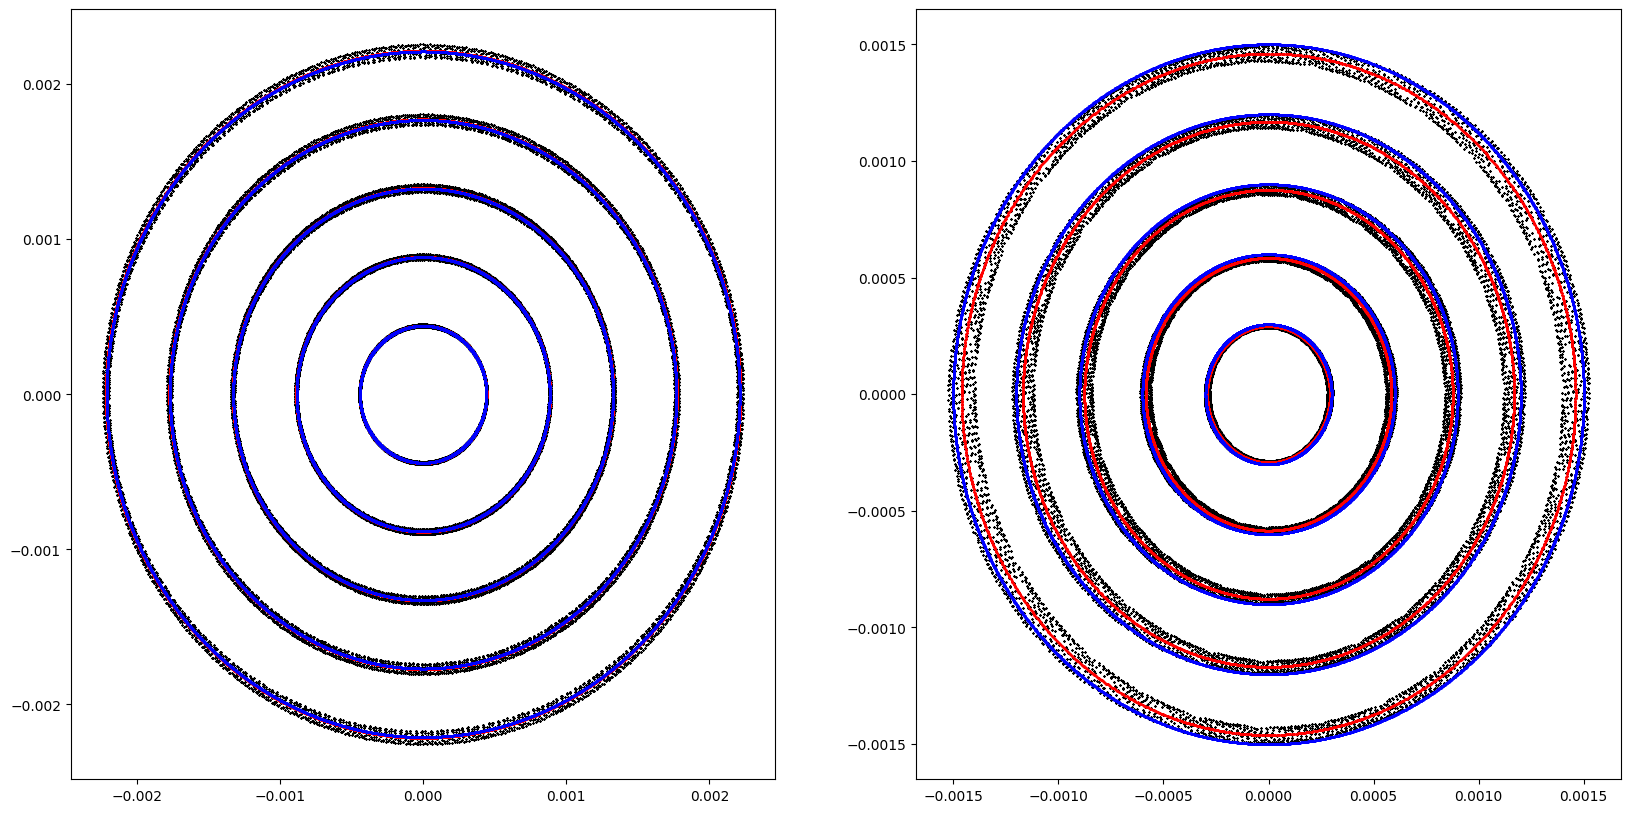

In [12]:
# Plot floquet trajectories
# Note, black points correspond to couped matrix with uncoupled normalization

plt.figure(figsize=(2*10, 10))

ax1 = plt.subplot(121)
for i in range(len(floquet1)):
    ax1.scatter(floquet3[i, 0], floquet3[i, 1], marker='x', s=1, color='black')
    ax1.scatter(floquet2[i, 0], floquet2[i, 1], marker='x', s=1, color='red')
    ax1.scatter(floquet1[i, 0], floquet1[i, 1], marker='o', s=1, color='blue')
    
ax2 = plt.subplot(122)
for i in range(len(floquet1)):
    ax2.scatter(floquet3[i, 2], floquet3[i, 3], marker='x', s=1, color='black')
    ax2.scatter(floquet2[i, 2], floquet2[i, 3], marker='x', s=1, color='red')
    ax2.scatter(floquet1[i, 2], floquet1[i, 3], marker='o', s=1, color='blue')
    
plt.show()

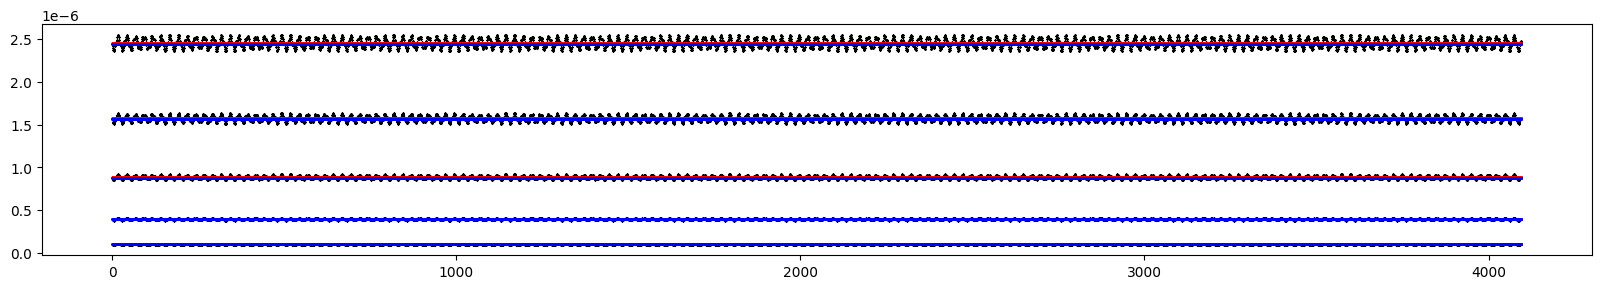

[5.0997389229254504e-21, 2.0398955691701802e-20, 5.432322743764921e-20, 8.159582276680721e-20, 1.236923690345037e-19]
[4.600590521905786e-21, 1.8402362087623144e-20, 4.3642171768193064e-20, 7.360944835049258e-20, 1.187957536783228e-19]
[2.1150693843072787e-09, 8.460277537229115e-09, 1.9035624458765503e-08, 3.384111014891646e-08, 5.287673460768206e-08]


In [13]:
# Plot invariants for x plane
# Note, black points correspond to couped matrix with uncoupled normalization

invariant1 = 0.5*(floquet1[:, 0]**2 + floquet1[:, 1]**2)
invariant2 = 0.5*(floquet2[:, 0]**2 + floquet2[:, 1]**2)
invariant3 = 0.5*(floquet3[:, 0]**2 + floquet3[:, 1]**2)

plt.figure(figsize=(20, 3))

for i in range(len(invariant1)):
    plt.scatter(range(length), invariant3[i].cpu().numpy(), marker='x', s=1, color='black')
    plt.scatter(range(length), invariant2[i].cpu().numpy(), marker='x', s=1, color='red')
    plt.scatter(range(length), invariant1[i].cpu().numpy(), marker='o', s=1, color='blue')
    
plt.show()

# Compute spread

print(list(invariant1.std(-1).cpu().numpy()))
print(list(invariant2.std(-1).cpu().numpy()))
print(list(invariant3.std(-1).cpu().numpy()))